<a href="https://colab.research.google.com/github/mzaib1012/Automated-PPG-Pulse-Oximetry-Calibration/blob/main/notebooks/ppg_spo2_calibration_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🩸 Dual-wavelength Red and Infrared PPG raw multi-channel telemetry streams generated.

🩺 CLINICAL BIOMEDICAL SpO2 CALIBRATION REPORT
  • Mean Extracted Ratio-of-Ratios (R) : 1.2092
  • Computed Blood Oxygen Level (SpO2)   : 79.77 %
  • Patient Health Diagnostics Status   : HYPOXIA WARNING


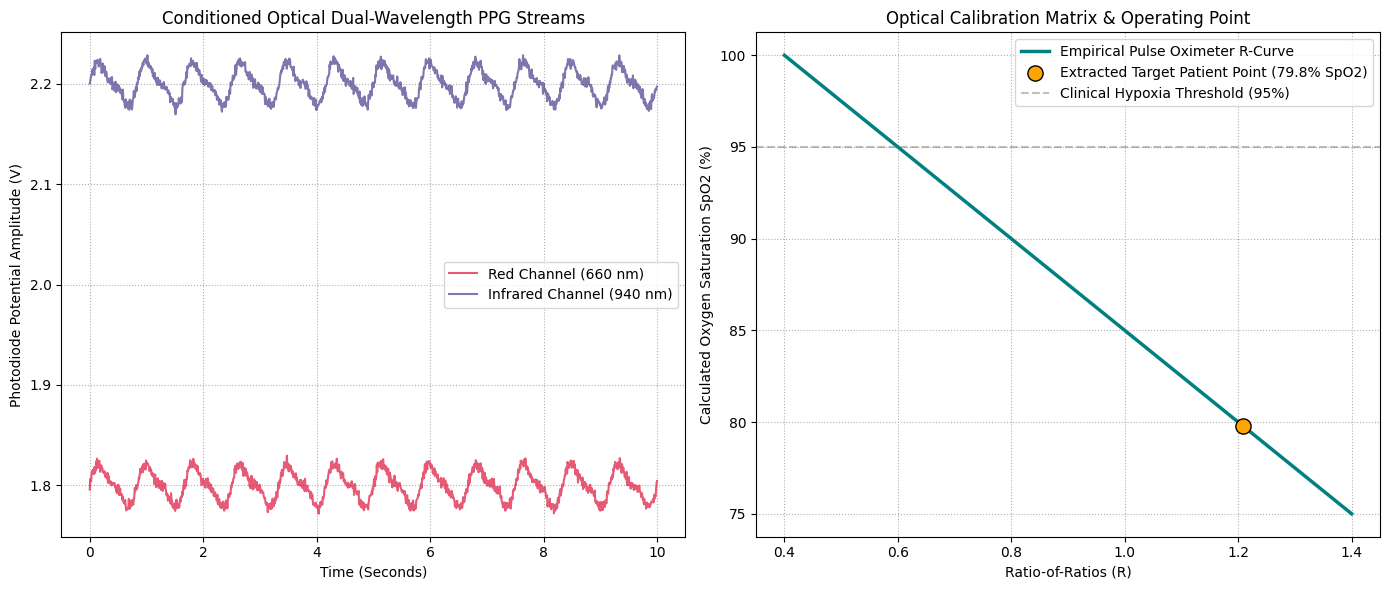

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Programmatically Generate Dual-Wavelength PPG Optical Signals ---
fs = 125.0  # Sampling frequency in Hz
duration = 10.0  # Duration in seconds
t = np.linspace(0, duration, int(fs * duration))

# Simulate cardiac pulse profile baseline (Heart Rate = 72 BPM -> 1.2 Hz)
cardiac_freq = 1.2
heart_beat_signal = 0.4 * np.sin(2 * np.pi * cardiac_freq * t) + 0.15 * np.sin(4 * np.pi * cardiac_freq * t)

# Set systemic physiology parameters: SpO2 target = 98%
# An SpO2 of 98% typically maps to an empirical R-ratio of roughly 0.65
dc_red = 1.8
ac_red_amplitude = 0.045
raw_red = dc_red + ac_red_amplitude * heart_beat_signal + np.random.normal(0, 0.003, len(t))

dc_ir = 2.2
ac_ir_amplitude = 0.046
raw_ir = dc_ir + ac_ir_amplitude * heart_beat_signal + np.random.normal(0, 0.003, len(t))

print("🩸 Dual-wavelength Red and Infrared PPG raw multi-channel telemetry streams generated.\n")

# --- 2. AC/DC Isolation & Extraction Component ---
def extract_ac_dc_components(signal, window_size=125):
    """
    Isolates the dynamic pulsing AC components and static DC baseline components
    using a sliding peak-to-peak tracking filter window.
    """
    dc_components = pd.Series(signal).rolling(window=window_size, center=True, min_periods=1).mean().values

    # AC is extracted by finding peak envelope variations around the tracked local baseline
    ac_peaks = pd.Series(signal).rolling(window=window_size, center=True, min_periods=1).max().values
    ac_troughs = pd.Series(signal).rolling(window=window_size, center=True, min_periods=1).min().values
    ac_components = ac_peaks - ac_troughs

    return ac_components, dc_components

ac_red, dc_filtered_red = extract_ac_dc_components(raw_red)
ac_ir, dc_filtered_ir = extract_ac_dc_components(raw_ir)

# --- 3. Ratio-of-Ratios (R) & Empirical SpO2 Calibration Tracking ---
# R = (AC_Red / DC_Red) / (AC_IR / DC_IR)
r_ratio_vector = (ac_red / dc_filtered_red) / (ac_ir / dc_filtered_ir)
mean_r = np.nanmean(r_ratio_vector[125:-125]) # Trim edges to remove rolling boundary anomalies

# Empirical linear calibration coefficient approximation (SpO2 = A - B*R)
# Standard medical instrumentation coefficients: A = 110, B = 25
A, B = 110.0, 25.0
calculated_spo2_profile = A - B * r_ratio_vector
final_estimated_spo2 = A - B * mean_r

print("="*70)
print("🩺 CLINICAL BIOMEDICAL SpO2 CALIBRATION REPORT")
print("="*70)
print(f"  • Mean Extracted Ratio-of-Ratios (R) : {mean_r:.4f}")
print(f"  • Computed Blood Oxygen Level (SpO2)   : {final_estimated_spo2:.2f} %")
print(f"  • Patient Health Diagnostics Status   : {'COMPLIANT (Normal)' if final_estimated_spo2 >= 95 else 'HYPOXIA WARNING'}")
print("="*70)

# --- 4. Quality Metric Profile Diagnostic Layout ---
plt.figure(figsize=(14, 6))

# Plot 1: Raw dual wavelength time-series pulse waveforms
plt.subplot(1, 2, 1)
plt.plot(t, raw_red, label='Red Channel (660 nm)', color='crimson', alpha=0.7)
plt.plot(t, raw_ir, label='Infrared Channel (940 nm)', color='darkslateblue', alpha=0.7)
plt.title('Conditioned Optical Dual-Wavelength PPG Streams')
plt.xlabel('Time (Seconds)')
plt.ylabel('Photodiode Potential Amplitude (V)')
plt.grid(True, linestyle=':')
plt.legend()

# Plot 2: Empirical R-Curve calibration plot mapping target point
plt.subplot(1, 2, 2)
r_curve_axis = np.linspace(0.4, 1.4, 100)
spo2_curve_axis = A - B * r_curve_axis
plt.plot(r_curve_axis, spo2_curve_axis, color='teal', lw=2.5, label='Empirical Pulse Oximeter R-Curve')
plt.scatter(mean_r, final_estimated_spo2, color='orange', s=120, zorder=5, edgecolor='black',
            label=f'Extracted Target Patient Point ({final_estimated_spo2:.1f}% SpO2)')
plt.title('Optical Calibration Matrix & Operating Point')
plt.xlabel('Ratio-of-Ratios (R)')
plt.ylabel('Calculated Oxygen Saturation SpO2 (%)')
plt.axhline(95.0, color='gray', linestyle='--', alpha=0.5, label='Clinical Hypoxia Threshold (95%)')
plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.savefig('ppg_spo2_calibration_report.png', dpi=300)
plt.show()